{download}`Download this notebook <#_logical_gates.ipynb>`

## Directed logical gates with `trainer.fit`

Short circuit-style networks trained with GradNet's built-in trainer. We allow positive/negative edges and rely on leaky-ReLU dynamics plus a bias node to fit XOR.


### Imports and helpers

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from gradnet import GradNet
from gradnet.trainer import fit
from gradnet.utils import plot_adjacency_heatmap, random_seed

random_seed(3)


### Truth tables and directed network
Layout: A, B, H, OUT. The initial state loads the two inputs and zeros elsewhere. We unroll `state = relu(A @ state)` for a few rounds and read the last node as the output. No clamping or masks beyond the zero diagonal from GradNet defaults.

In [2]:
device = torch.device("cpu")
inputs = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], device=device)

gate_targets = {
    "AND": inputs.new_tensor([0.,0.,0.,1.]),
    "OR":  inputs.new_tensor([0.,1.,1.,1.]),
    "XOR": inputs.new_tensor([0.,1.,1.,0.]),
}

# Layout: A, B, H, OUT
num_nodes = 4
input_idx = (0, 1)
output_idx = num_nodes - 1
num_rounds = 2
budget = 10.


### Propagation, loss, and training via `fit`
Unroll `state = relu(A @ state)` for `num_rounds` starting from the input-loaded state; the output is the last node passed through a sigmoid and BCE loss. No clamping beyond the initial state.

In [3]:
def propagate(A, x, rounds=num_rounds):
    state = torch.zeros(num_nodes, device=A.device, dtype=A.dtype)
    state[list(input_idx)] = x
    for _ in range(rounds):
        state = torch.tanh(A @ state)
    return state[output_idx]


def gate_loss(gn, targets):
    A = gn()
    preds = torch.stack([propagate(A, x) for x in inputs])
    loss = F.mse_loss(preds, targets)
    acc = ((preds > 0.5) == (targets > 0.5)).float().mean()
    return loss, {"acc": acc}


def train_gate(name, targets, num_updates=2000, lr=0.01):
    gn = GradNet(
        num_nodes=num_nodes,
        budget=budget,
        undirected=False,
        delta_sign="free",
        rand_init_weights=0.0001,
        use_budget_up=False,
    )

    loss_fn = lambda g: gate_loss(g, targets)
    fit(
        gn=gn,
        loss_fn=loss_fn,
        num_updates=num_updates,
        optim_cls=torch.optim.Adam,
        optim_kwargs={"lr": lr},
        logger=False,
        accelerator="cpu",
    )

    with torch.no_grad():
        A = gn()
        preds = torch.stack([propagate(A, x) for x in inputs]).cpu()
    return gn, A.detach().cpu(), preds, targets.detach().cpu()


### Train AND, OR, and XOR

In [4]:
gate_results = {}
for name, targets in gate_targets.items():
    print(f"Training {name} gate")
    gn, adj, preds, tgts = train_gate(name, targets)
    gate_results[name] = {"model": gn, "adj": adj, "preds": preds, "targets": tgts}


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training AND gate


Updates:   0%|          | 0/2000 [00:00<?, ?it/s]


  | Name | Type    | Params | Mode 
-----------------------------------------
0 | gn   | GradNet | 16     | train
-----------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=2000` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training OR gate


Updates:   0%|          | 0/2000 [00:00<?, ?it/s]


  | Name | Type    | Params | Mode 
-----------------------------------------
0 | gn   | GradNet | 16     | train
-----------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=2000` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training XOR gate


Updates:   0%|          | 0/2000 [00:00<?, ?it/s]


  | Name | Type    | Params | Mode 
-----------------------------------------
0 | gn   | GradNet | 16     | train
-----------------------------------------
16        Trainable params
0         Non-trainable params
16        Total params
0.000     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=2000` reached.


### Check truth tables after training

In [5]:
for name, res in gate_results.items():
    print(f"{name} gate outputs")
    for combo, pred, target in zip(inputs.cpu().tolist(), res["preds"], res["targets"]):
        bits = [int(v) for v in combo]
        print(f"{bits} -> pred={pred.item():.3f} (binary {int(pred > 0.5)}), target={int(target.item())}")


AND gate outputs
[0, 0] -> pred=0.000 (binary 0), target=0
[0, 1] -> pred=0.040 (binary 0), target=0
[1, 0] -> pred=0.075 (binary 0), target=0
[1, 1] -> pred=0.782 (binary 1), target=1
OR gate outputs
[0, 0] -> pred=0.000 (binary 0), target=0
[0, 1] -> pred=0.955 (binary 1), target=1
[1, 0] -> pred=0.968 (binary 1), target=1
[1, 1] -> pred=0.998 (binary 1), target=1
XOR gate outputs
[0, 0] -> pred=0.000 (binary 0), target=0
[0, 1] -> pred=0.675 (binary 1), target=1
[1, 0] -> pred=0.674 (binary 1), target=1
[1, 1] -> pred=0.197 (binary 0), target=0


### Plot the directed adjacencies

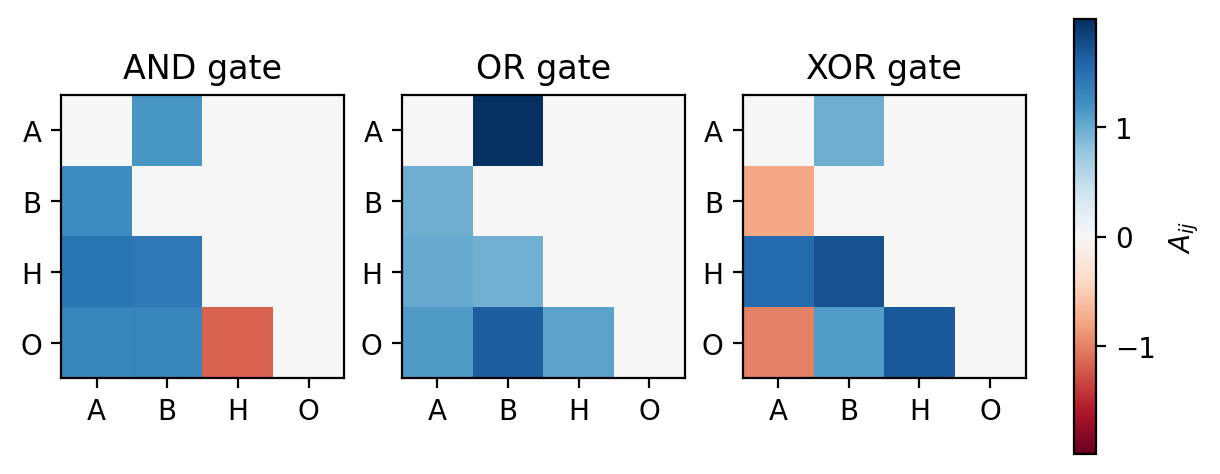

In [6]:

abs_max = max(float(res["adj"].abs().max()) for res in gate_results.values())
abs_max = max(abs_max, 1e-6)
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0.0, vmax=abs_max)
imshow_kwargs = {"cmap": "RdBu", "norm": norm}

# Node labels for ticks: A, B, hidden(s) as H/H1..., and O for output
hidden_counter = 0
node_labels = []
for n in range(num_nodes):
    if n == input_idx[0]:
        node_labels.append("A")
    elif len(input_idx) > 1 and n == input_idx[1]:
        node_labels.append("B")
    elif n == output_idx:
        node_labels.append("O")
    else:
        label = "H" if hidden_counter == 0 else f"H{hidden_counter}"
        node_labels.append(label)
        hidden_counter += 1

fig, axs = plt.subplots(1, 3, figsize=(6, 2.5), dpi=200, constrained_layout=True)
for ax, (name, res) in zip(axs, gate_results.items()):
    plot_adjacency_heatmap(res["adj"], ax=ax, title=f"{name} gate", imshow_kwargs=imshow_kwargs, add_colorbar=False)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_xticks(range(num_nodes), node_labels)
    ax.set_yticks(range(num_nodes), node_labels)

cbar = fig.colorbar(axs[-1].images[0], ax=axs, location="right", shrink=0.9)
cbar.set_label("$A_{ij}$")
plt.show()


/var/folders/72/79vqt54j447byqmvb80g_n3w0000gn/T/ipykernel_47710/3576067285.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  edge_cmap = mpl.cm.get_cmap('RdBu')  # red = negative, blue = positive


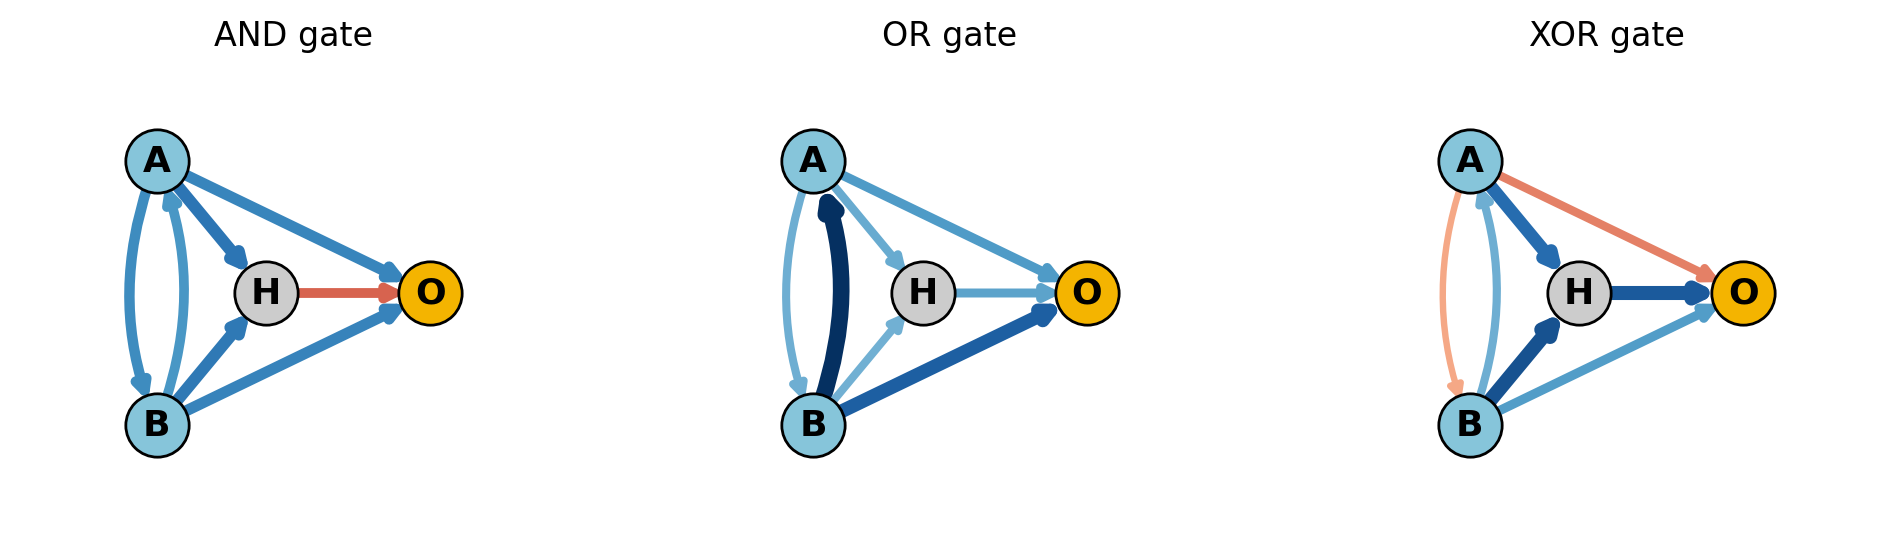

In [7]:

# Plot each learned gate as a small directed graph
import math
import matplotlib as mpl

# Re-compute a shared scale so widths/colors are comparable across gates
edge_abs_max = max(float(res['adj'].abs().max()) for res in gate_results.values())
edge_abs_max = max(edge_abs_max, 1e-8)
edge_norm = mpl.colors.TwoSlopeNorm(vmin=-edge_abs_max, vcenter=0.0, vmax=edge_abs_max)
edge_cmap = mpl.cm.get_cmap('RdBu')  # red = negative, blue = positive

dx = 0.4
dy = 1.6

node_labels = {0: 'A', 1: 'B', output_idx: 'O'}
if num_nodes >= 3:
    node_labels.setdefault(2, 'H')


def layout_positions(num_nodes, input_idx, output_idx):
    # Inputs stacked on the left (x=0)
    inputs = list(input_idx)
    y_inputs = [(((len(inputs) - 1) / 2) - i)*dy for i in range(len(inputs))]
    positions = {idx: (0.0, y) for idx, y in zip(inputs, y_inputs)}

    # Middle layer for all other non-output nodes
    mid_nodes = [i for i in range(num_nodes) if i not in inputs and i != output_idx]
    if mid_nodes:
        y_mid = [(((len(mid_nodes) - 1) / 2) - i)*dy for i in range(len(mid_nodes))]
        for idx, y in zip(mid_nodes, y_mid):
            positions[idx] = (dx, y)

    # Output on the right (x=2) centered relative to current nodes
    if positions:
        min_y = min(y for _, y in positions.values())
        max_y = max(y for _, y in positions.values())
        out_y = 0.5 * (min_y + max_y)
    else:
        out_y = 0.0
    positions[output_idx] = (2.5*dx, out_y)
    return positions


def draw_gate_graph(name, adj, ax):
    adj_np = adj.detach().cpu().numpy()
    pos = layout_positions(adj_np.shape[0], input_idx, output_idx)
    threshold = 1e-2
    curve_rad = 0.20  # clockwise bend for bidirectional pairs

    # Draw directed edges j -> i with styling from weight
    for i in range(adj_np.shape[0]):
        for j in range(adj_np.shape[1]):
            w = adj_np[i, j]
            if abs(w) < threshold:
                continue
            (x0, y0), (x1, y1) = pos[j], pos[i]
            width = 6.0 * (abs(w) / edge_abs_max)
            color = edge_cmap(edge_norm(w))

            has_reverse = i != j and abs(adj_np[j, i]) >= threshold
            rad = curve_rad if has_reverse else 0.0

            ax.annotate(
                '',
                xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=color,
                    lw=width,
                    alpha=1,
                    shrinkA=9, shrinkB=9,
                    connectionstyle=f'arc3,rad={rad}',
                ),
                zorder=1,
            )

    # Draw nodes on top of edges
    for idx, (x, y) in pos.items():
        kind = 'input' if idx in input_idx else ('output' if idx == output_idx else 'hidden')
        facecolor = {'input': '#86c5da', 'hidden': '#cccccc', 'output': '#f4b400'}[kind]
        ax.scatter(x, y, s=520, color=facecolor, edgecolor='k', zorder=2)
        label = node_labels.get(idx, f'n{idx}')
        ax.text(x, y, label, ha='center', va='center', weight='bold', fontsize=13)

    ys = [y for _, y in pos.values()]
    y_margin = 0.6 if len(ys) > 1 else 0.4
    ax.set_title(f"{name} gate")
    ax.set_xlim(-0.5, 2.5*dx + 0.5)
    ax.set_ylim(min(ys) - y_margin, max(ys) + y_margin)
    ax.axis('off')


fig, axes = plt.subplots(1, len(gate_results), figsize=(4 * len(gate_results), 3), dpi=200)
if len(gate_results) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, gate_results.items()):
    draw_gate_graph(name, res['adj'], ax)

plt.show()
